# **Modelling the Spread of Rent Inflation across States in the US through a Combined Spatial Analysis and Diffusion Modeling Approach**

<br>

<br>

*Week 4 - Diffusion Modelling*

In [884]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Plot Specifications
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})


In [885]:
def set_seed(seed=9):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(9)

# Loading Datasets

In [886]:
# Getting cleaned and merged per state data
merged_df_final = pd.read_csv("merged_df_final.csv")
# Getting Overview
merged_df_final.head()

,Unnamed: 0,county_name,year,GDP_PI,rent_50_0,rent_50_1,rent_50_2,rent_50_3,rent_50_4,housing_units,personal_income
0,0.0,ALBANY,2001.0,13068721.0,444.0,547.0,672.0,844.0,943.0,133501.0,11476555.0
1,1.0,ALBANY,2002.0,13424897.0,444.0,547.0,672.0,844.0,943.0,133501.0,11476555.0
2,2.0,ALBANY,2003.0,14257327.0,444.0,547.0,672.0,844.0,943.0,133501.0,11476555.0
3,3.0,ALBANY,2004.0,14897956.0,444.0,548.0,673.0,844.0,943.0,133501.0,11476555.0
4,4.0,ALBANY,2005.0,15541573.0,569.0,600.0,719.0,862.0,927.0,133501.0,11476555.0


In [887]:
# Sorting data
df = merged_df_final.sort_values(["year", "county_name"]).reset_index(drop=True)
df.head()


,Unnamed: 0,county_name,year,GDP_PI,rent_50_0,rent_50_1,rent_50_2,rent_50_3,rent_50_4,housing_units,personal_income
0,0.0,ALBANY,2001.0,13068721.0,444.0,547.0,672.0,844.0,943.0,133501.0,11476555.0
1,26.0,ALLEGANY,2001.0,689784.0,399.0,447.0,537.0,695.0,794.0,25047.0,1148267.0
2,52.0,BRONX,2001.0,17568178.0,898.0,1001.0,1137.0,1422.0,1593.0,508895.0,32553078.0
3,78.0,BROOME,2001.0,5435556.0,398.0,446.0,557.0,707.0,793.0,89117.0,5678460.0
4,104.0,CATTARAUGUS,2001.0,1574186.0,399.0,447.0,537.0,695.0,794.0,40612.0,2193492.0


# Feature Engineering

In [888]:
# Getting Percentages Changes
df["rent_growth_50_0"] = df.groupby("county_name")["rent_50_0"].pct_change()
df["rent_growth_50_1"] = df.groupby("county_name")["rent_50_1"].pct_change()
df["rent_growth_50_2"] = df.groupby("county_name")["rent_50_2"].pct_change()
df["rent_growth_50_3"] = df.groupby("county_name")["rent_50_3"].pct_change()
df["rent_growth_50_4"] = df.groupby("county_name")["rent_50_4"].pct_change()
df.head()

,Unnamed: 0,county_name,year,GDP_PI,rent_50_0,rent_50_1,rent_50_2,rent_50_3,rent_50_4,housing_units,personal_income,rent_growth_50_0,rent_growth_50_1,rent_growth_50_2,rent_growth_50_3,rent_growth_50_4
0,0.0,ALBANY,2001.0,13068721.0,444.0,547.0,672.0,844.0,943.0,133501.0,11476555.0,NaN,NaN,NaN,NaN,NaN
1,26.0,ALLEGANY,2001.0,689784.0,399.0,447.0,537.0,695.0,794.0,25047.0,1148267.0,NaN,NaN,NaN,NaN,NaN
2,52.0,BRONX,2001.0,17568178.0,898.0,1001.0,1137.0,1422.0,1593.0,508895.0,32553078.0,NaN,NaN,NaN,NaN,NaN
3,78.0,BROOME,2001.0,5435556.0,398.0,446.0,557.0,707.0,793.0,89117.0,5678460.0,NaN,NaN,NaN,NaN,NaN
4,104.0,CATTARAUGUS,2001.0,1574186.0,399.0,447.0,537.0,695.0,794.0,40612.0,2193492.0,NaN,NaN,NaN,NaN,NaN


In [889]:
# Setting 0 rent growth rate at origin (2001)
df["rent_growth_50_0"] = df["rent_growth_50_0"].fillna(0)
df["rent_growth_50_1"] = df["rent_growth_50_1"].fillna(0)
df["rent_growth_50_2"] = df["rent_growth_50_2"].fillna(0)
df["rent_growth_50_3"] = df["rent_growth_50_3"].fillna(0)
df["rent_growth_50_4"] = df["rent_growth_50_4"].fillna(0)

# EDA - Distributions

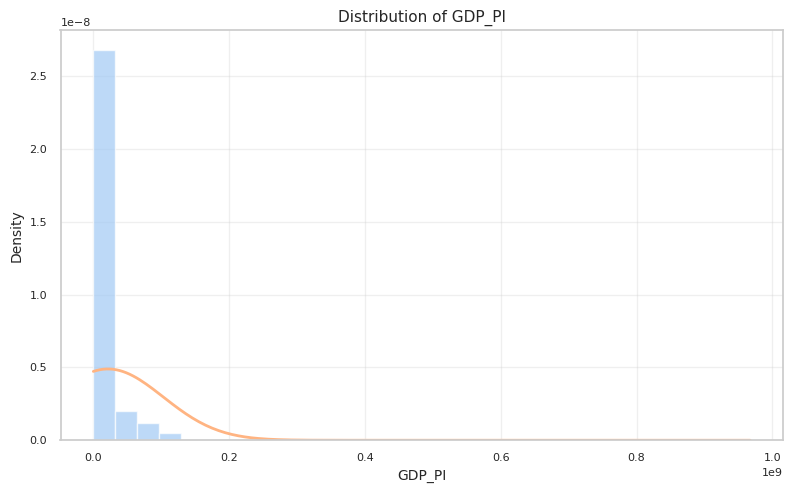

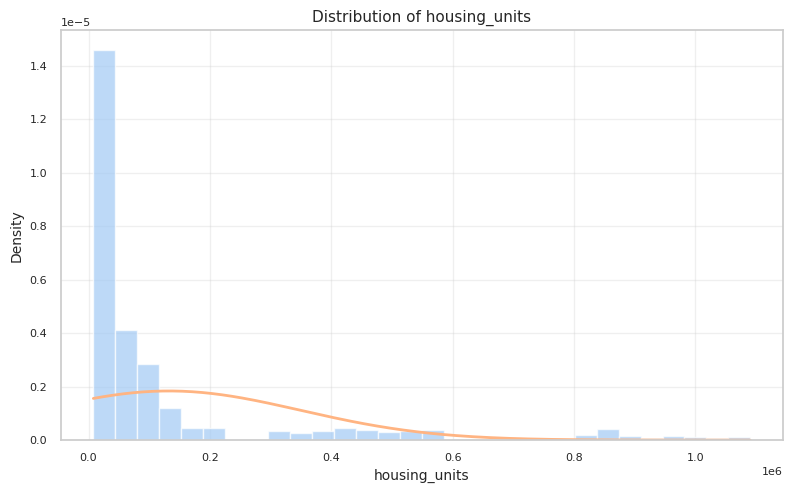

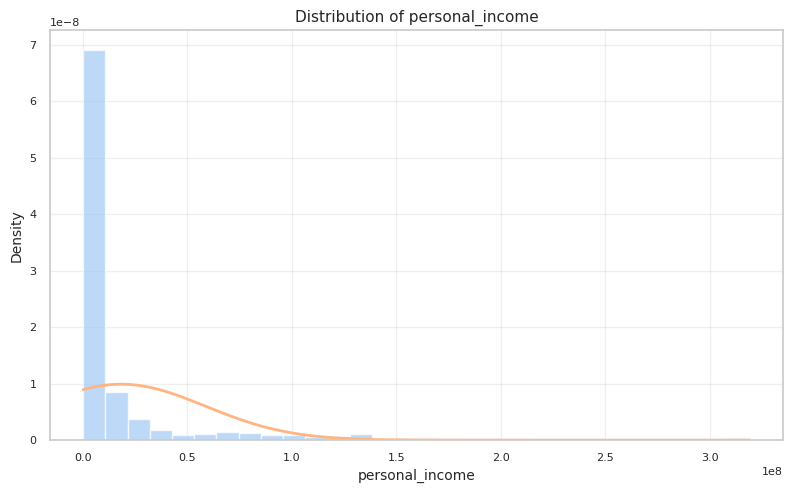

In [890]:
cols = ["GDP_PI", "housing_units", "personal_income"]

for col in cols:
    data = df[col].dropna()

    mu, std = data.mean(), data.std()

    plt.figure(figsize=(8, 5))

    # Histogram
    plt.hist(data, bins=30, density=True, alpha=0.7)

    # Normal curve
    x = np.linspace(data.min(), data.max(), 200)
    y = norm.pdf(x, mu, std)
    plt.plot(x, y, linewidth=2)

    # Titles and labels
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

    # Clean layout
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


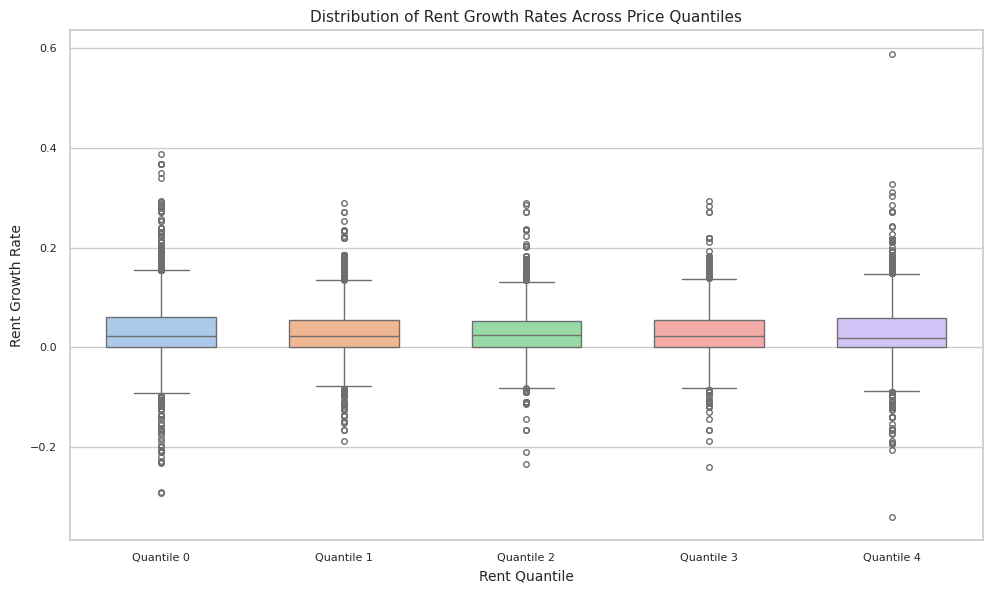

In [891]:
# Columns with rent growth rates
rent_growth_cols = [
    "rent_growth_50_0",
    "rent_growth_50_1",
    "rent_growth_50_2",
    "rent_growth_50_3",
    "rent_growth_50_4"
]

rent_grwoth_df = df[rent_growth_cols]

# Seaborn Theme
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

plt.figure(figsize=(10, 6))
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

# Boxplot
sns.boxplot(data=rent_grwoth_df, width=0.6, fliersize=4)

# Titles and labels
plt.title("Distribution of Rent Growth Rates Across Price Quantiles")
plt.xlabel("Rent Quantile")
plt.ylabel("Rent Growth Rate")
plt.xticks(ticks=range(len(rent_growth_cols)), labels=[f"Quantile {i}" for i in range(5)])

plt.tight_layout()
plt.show()


# Getting Long Format Data

In [892]:
# Importing long format data
df_long = pd.read_csv("merged_df_final_long.csv")
df_long.head()

,Unnamed: 0,county_name,year,GDP_PI,housing_units,personal_income,house_size,rent,rent_growth
0,0.0,ALBANY,2001.0,13068721.0,133501.0,11476555.0,0.0,444.0,NaN
1,1.0,ALBANY,2002.0,13424897.0,133501.0,11476555.0,0.0,444.0,0.000000
2,2.0,ALBANY,2003.0,14257327.0,133501.0,11476555.0,0.0,444.0,0.000000
3,3.0,ALBANY,2004.0,14897956.0,133501.0,11476555.0,0.0,444.0,0.000000
4,4.0,ALBANY,2005.0,15541573.0,133501.0,11476555.0,0.0,569.0,0.281532


In [893]:
# Dropping NAs from creation of rent growth - first year has no rent growth
df_long = df_long.dropna()

# Data Preprocessing

In [894]:
# Defining features and targets
features = [
    "GDP_PI",
    "housing_units",
    "personal_income",
    "house_size"
]

target = "rent"


In [895]:
import geopandas as gpd
import numpy as np
import libpysal
from libpysal.weights import Queen


# Loading County Shapefile

counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
)

# Filtering for New York State only (FIPS = 36)

ny_counties = counties[counties["STATEFP"] == "36"].copy()

# Creating standardized county names (Uppercase)

ny_counties["county_name"] = (
    ny_counties["NAME"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# Building Spatial Weights (County Neighborhood Structure)

w = Queen.from_dataframe(ny_counties)

# Converting to Adjacent Matrix

county_list = ny_counties["county_name"].tolist()
county_index = {c: i for i, c in enumerate(county_list)}

N = len(county_list)
A = np.zeros((N, N))

for i, neighbors in w.neighbors.items():
    for j in neighbors:
        A[i, j] = 1
        A[j, i] = 1

print("Adjacency matrix shape:", A.shape)

# Channels Paramter

C = len(features) + 1

/tmp/ipykernel_1503/233487222.py:28: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(ny_counties)


Adjacency matrix shape: (62, 62)


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 38.
  W.__init__(self, neighbors, ids=ids, **kw)


In [896]:
# Converting Adjacent Matrix to Spatial Grid
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from tqdm import tqdm

# ordering (NY counties)
counties = list(ny_counties["county_name"])

N = len(counties)

# PCA embedding of spatial adjacency matrix
coords = PCA(n_components=2, random_state=42).fit_transform(A)

# normalize coords
coords = MinMaxScaler().fit_transform(coords)

# grid size (62 counties → 8x8 grid = 64 slots)
H, W = 8, 8

# convert coordinates to initial grid positions
rows = (coords[:, 1] * (H - 1)).astype(int)
cols = (coords[:, 0] * (W - 1)).astype(int)

# flatten grid slots for fast assignment
available_slots = [(r, c) for r in range(H) for c in range(W)]

occupied = set()
clean_county_to_pos = {}

# sort counties for stable assignment
order = np.argsort(rows + cols)

for idx in order:
    county = counties[idx]

    # assign next available slot (O(1))
    for slot in available_slots:
        if slot not in occupied:
            clean_county_to_pos[county] = slot
            occupied.add(slot)
            break

# mapping county to position
county_to_pos = clean_county_to_pos

In [897]:
# Cleaning county names
def clean_county(x):
    return (
        str(x)
        .upper()
        .replace(".", "")
        .replace(" COUNTY", "")
        .replace(" ST ", " SAINT ")
        .strip()
    )

df_long["county_name"] = df_long["county_name"].apply(clean_county)
county_to_pos = {
    clean_county(k): v
    for k, v in county_to_pos.items()
}

In [898]:
# Checking cleaning of county names
missing = set(df_long["county_name"]) - set(county_to_pos.keys())
print(missing)

set()


In [899]:
# Time-based Data Partitioning at year = 2015
train_df = df_long[df_long["year"] < 2015].copy()
test_df  = df_long[df_long["year"] >= 2015].copy()

In [900]:
print("train_df", train_df.shape)
print("test_df", test_df.shape)

train_df (4030, 9)
test_df (3735, 9)


In [901]:
# Normalizing the data
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_df[features] = feature_scaler.fit_transform(train_df[features])
test_df[features]  = feature_scaler.transform(test_df[features])

train_df[[target]] = target_scaler.fit_transform(train_df[[target]])
test_df[[target]]  = target_scaler.transform(test_df[[target]])

# Tensor Builder Function

In [902]:
def build_tensor(dataframe):
    years = sorted(dataframe["year"].unique())
    T = len(years)

    tensor = np.zeros((T, C, H, W))

    for t, year in enumerate(years):
        df_year = dataframe[dataframe["year"] == year]

        for _, row in df_year.iterrows():
            i, j = county_to_pos[row["county_name"]]

            tensor[t, :-1, i, j] = row[features].values
            tensor[t, -1, i, j]  = row[target]

    return tensor, years


## Train and Test Tensors

In [903]:
train_tensor, train_years = build_tensor(train_df)
test_tensor, test_years   = build_tensor(test_df)


In [904]:
len(train_df["county_name"].unique())

62

In [905]:
print(type(train_tensor))
print(np.shape(train_tensor))
print("years:", train_years)

<class 'numpy.ndarray'>
(13, 5, 8, 8)
years: [np.float64(2002.0), np.float64(2003.0), np.float64(2004.0), np.float64(2005.0), np.float64(2006.0), np.float64(2007.0), np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0)]


In [906]:
print(type(test_tensor))
print(np.shape(test_tensor))
print("years:", test_years)

<class 'numpy.ndarray'>
(12, 5, 8, 8)
years: [np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0), np.float64(2025.0), np.float64(2026.0)]


# Sequence Creation

In [907]:
SEQ_LEN = 2

def create_sequences(data_tensor):
    X, y = [], []
    T = data_tensor.shape[0]

    if T <= SEQ_LEN:
        raise ValueError(
            f"Not enough timesteps: T={T}, SEQ_LEN={SEQ_LEN}"
        )

    for t in range(T - SEQ_LEN):
        X.append(data_tensor[t:t+SEQ_LEN])
        y.append(data_tensor[t+SEQ_LEN, -1])

    return np.stack(X), np.stack(y)

X_train, y_train = create_sequences(train_tensor)
X_test, y_test = create_sequences(test_tensor)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(11, 2, 5, 8, 8)
(11, 8, 8)
(10, 2, 5, 8, 8)
(10, 8, 8)


# ConvLSTM Model

In [908]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        padding = kernel_size // 2

        self.hidden_dim = hidden_dim

        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            4 * hidden_dim,
            kernel_size,
            padding=padding
        )

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        conv_out = self.conv(combined)

        cc_i, cc_f, cc_o, cc_g = torch.split(conv_out, self.hidden_dim, dim=1)

        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)

        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)

        return h_next, c_next


class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()

        self.cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)
        self.conv_out = nn.Conv2d(hidden_dim, 1, kernel_size=1)

    def forward(self, x):
        B, T, C, H, W = x.shape

        h = torch.zeros(B, self.cell.hidden_dim, H, W).to(x.device)
        c = torch.zeros(B, self.cell.hidden_dim, H, W).to(x.device)

        for t in range(T):
            h, c = self.cell(x[:, t], h, c)

        out = self.conv_out(h)
        return out.squeeze(1)


# Data Loaders

In [909]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    ),
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32)
    ),
    batch_size=8,
    shuffle=False
)


# Training

In [910]:
model = ConvLSTM(input_dim=C, hidden_dim=64, kernel_size=3).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

criterion = nn.HuberLoss()

train_losses = []

EPOCHS = 600

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        preds = model(xb)
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.6f}")

Epoch 1, Train Loss: 0.495931
Epoch 2, Train Loss: 0.505429
Epoch 3, Train Loss: 0.470339
Epoch 4, Train Loss: 0.479058
Epoch 5, Train Loss: 0.369450
Epoch 6, Train Loss: 0.413362
Epoch 7, Train Loss: 0.372587
Epoch 8, Train Loss: 0.340065
Epoch 9, Train Loss: 0.297249
Epoch 10, Train Loss: 0.273396
Epoch 11, Train Loss: 0.245532
Epoch 12, Train Loss: 0.248318
Epoch 13, Train Loss: 0.235307
Epoch 14, Train Loss: 0.239428
Epoch 15, Train Loss: 0.238603
Epoch 16, Train Loss: 0.226344
Epoch 17, Train Loss: 0.217789
Epoch 18, Train Loss: 0.208847
Epoch 19, Train Loss: 0.189232
Epoch 20, Train Loss: 0.181668
Epoch 21, Train Loss: 0.183421
Epoch 22, Train Loss: 0.173995
Epoch 23, Train Loss: 0.173769
Epoch 24, Train Loss: 0.177325
Epoch 25, Train Loss: 0.165764
Epoch 26, Train Loss: 0.164703
Epoch 27, Train Loss: 0.159010
Epoch 28, Train Loss: 0.144244
Epoch 29, Train Loss: 0.142895
Epoch 30, Train Loss: 0.144313
Epoch 31, Train Loss: 0.132032
Epoch 32, Train Loss: 0.127131
Epoch 33, Train L

## Loss Curve

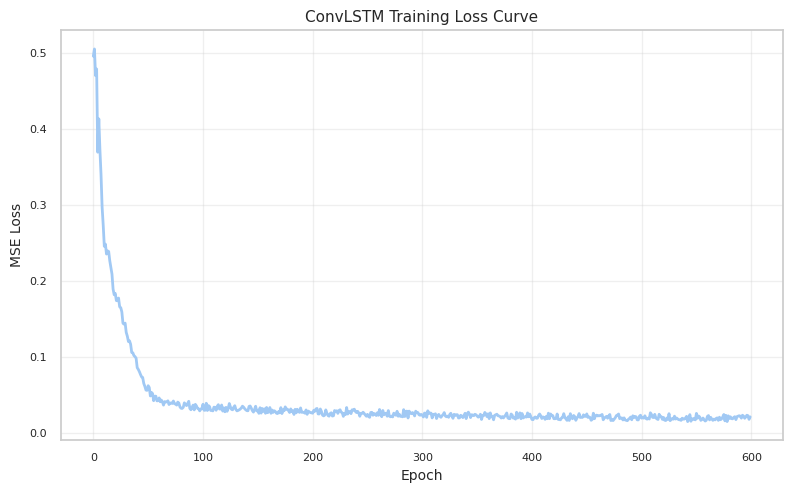

In [911]:
plt.figure(figsize=(8, 5))
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

plt.plot(train_losses, linewidth=2)

plt.title("ConvLSTM Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance

In [912]:
# Evaluation
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

def evaluate_model(model, loader):
    model.eval()
    losses = []
    criterion = nn.MSELoss()

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            losses.append(loss.item())

    return np.mean(losses)


# Baseline Performance
baseline_loss = evaluate_model(model, test_loader)
print("Baseline Loss:", baseline_loss)


# Feature Importance

def permute_feature_tensor(x, feature_idx):
    x = x.copy()

    B, T, C, H, W = x.shape

    flat = x[:, :, feature_idx, :, :].reshape(-1)
    flat = np.random.permutation(flat)
    x[:, :, feature_idx, :, :] = flat.reshape(B, T, H, W)

    return x


def feature_importance(model, X_test, y_test, feature_names):

    model.eval()

    base_loss = evaluate_model(model, test_loader)

    importances = []

    n_features = len(feature_names)

    # safety check
    assert X_test.shape[2] >= n_features, (
        f"Mismatch: X_test has {X_test.shape[2]} channels "
        f"but only {n_features} feature names"
    )

    for f in range(n_features):

        X_permuted = permute_feature_tensor(X_test, f)

        loader = DataLoader(
            TensorDataset(
                torch.tensor(X_permuted, dtype=torch.float32),
                torch.tensor(y_test, dtype=torch.float32)
            ),
            batch_size=8,
            shuffle=False
        )

        perm_loss = evaluate_model(model, loader)

        importance = perm_loss - base_loss
        importances.append(importance)

        print(f"{feature_names[f]}: {importance:.6f}")

    return importances


# Run
feature_names = features
importances = feature_importance(model, X_test, y_test, feature_names)

Baseline Loss: 1.0916777849197388
GDP_PI: 0.263829
housing_units: 0.095719
personal_income: 0.382694
house_size: 0.010213


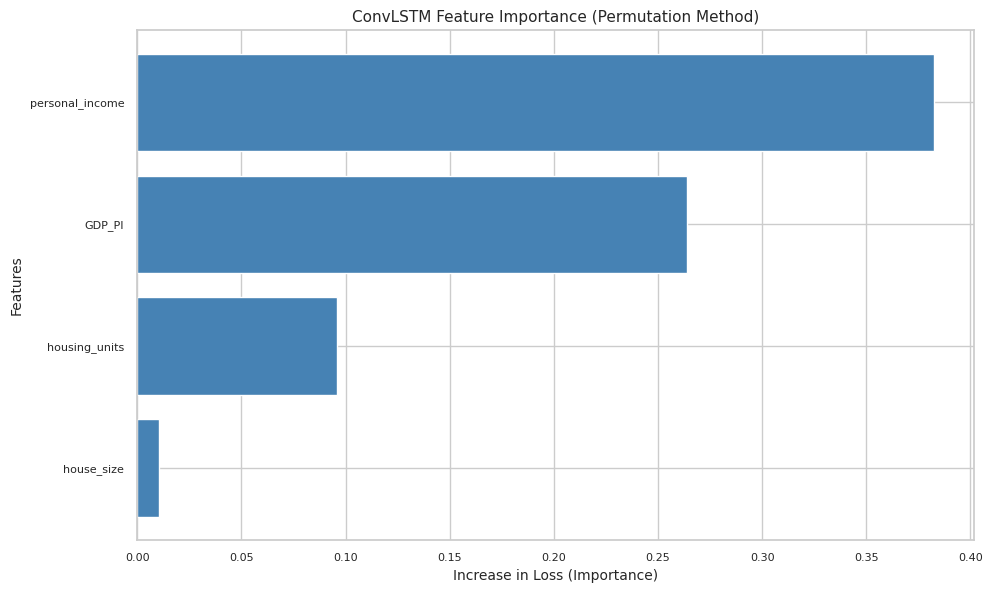

In [913]:
import numpy as np
import matplotlib.pyplot as plt

idx = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(
    np.array(feature_names)[idx],
    np.array(importances)[idx],
    color="steelblue"
)

plt.xlabel("Increase in Loss (Importance)")
plt.ylabel("Features")
plt.title("ConvLSTM Feature Importance (Permutation Method)")
plt.gca()

plt.tight_layout()
plt.show()

# Test Evaluation

In [914]:
model.eval()

preds_list = []
actuals_list = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)

        preds = model(xb)

        preds_list.append(preds.cpu().numpy())
        actuals_list.append(yb.numpy())

preds_all = np.concatenate(preds_list)
actuals_all = np.concatenate(actuals_list)


## Inverse Transform

In [915]:
preds_flat = preds_all.reshape(-1, 1)
actuals_flat = actuals_all.reshape(-1, 1)

preds_inv = target_scaler.inverse_transform(preds_flat)
actuals_inv = target_scaler.inverse_transform(actuals_flat)


In [916]:
# Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(actuals_inv, preds_inv))
mae  = mean_absolute_error(actuals_inv, preds_inv)
r2 = r2_score(actuals_inv, preds_inv)

print(f"Test RMSE (growth): {rmse:.6f}")
print(f"Test MAE  (growth): {mae:.6f}")
print(f"Test R2 (growth): {r2:.6f}")


Test RMSE (growth): 314.672238
Test MAE  (growth): 211.155426
Test R2 (growth): 0.828419


## Diffusion over Time

In [917]:
# Mapping of county to numbers for ploting
ny_counties_1 = df_long.county_name.unique().tolist()
print(ny_counties_1)

# Creating keys
county_to_id = {county: i+1 for i, county in enumerate(ny_counties_1)}
id_to_county = {i+1: county for i, county in enumerate(ny_counties_1)}

pos_to_county = {
    pos: county_to_id[name]
    for name, pos in county_to_pos.items()
}



['ALBANY', 'ALLEGANY', 'BRONX', 'BROOME', 'CATTARAUGUS', 'CAYUGA', 'CHAUTAUQUA', 'CHEMUNG', 'CHENANGO', 'CLINTON', 'COLUMBIA', 'CORTLAND', 'DELAWARE', 'DUTCHESS', 'ERIE', 'ESSEX', 'FRANKLIN', 'FULTON', 'GENESEE', 'GREENE', 'HAMILTON', 'HERKIMER', 'JEFFERSON', 'KINGS', 'LEWIS', 'LIVINGSTON', 'MADISON', 'MONROE', 'MONTGOMERY', 'NASSAU', 'NEW YORK', 'NIAGARA', 'ONEIDA', 'ONONDAGA', 'ONTARIO', 'ORANGE', 'ORLEANS', 'OSWEGO', 'OTSEGO', 'PUTNAM', 'QUEENS', 'RENSSELAER', 'RICHMOND', 'ROCKLAND', 'SARATOGA', 'SCHENECTADY', 'SCHOHARIE', 'SCHUYLER', 'SENECA', 'ST LAWRENCE', 'STEUBEN', 'SUFFOLK', 'SULLIVAN', 'TIOGA', 'TOMPKINS', 'ULSTER', 'WARREN', 'WASHINGTON', 'WAYNE', 'WESTCHESTER', 'WYOMING', 'YATES']


In [918]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_time_evolution(preds, actuals, county_to_pos, county_to_id, timesteps=5):

    n_samples = preds.shape[0]
    timesteps = min(timesteps, n_samples)

    pos_to_county = {pos: county for county, pos in county_to_pos.items()}

    fig, axes = plt.subplots(2, timesteps, figsize=(3*timesteps, 6))

    if timesteps == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for t in range(timesteps):

        sns.heatmap(actuals[t], ax=axes[0, t],
                    cmap='RdBu_r', center=0.95, cbar=False)

        axes[0, t].set_title(f"Actual t={t}")

        H, W = actuals[t].shape
        for i in range(H):
            for j in range(W):
                if (i, j) in pos_to_county:
                    county = pos_to_county[(i, j)]
                    axes[0, t].text(
                        j + 0.5, i + 0.5,
                        county_to_id[county],
                        ha='center', va='center',
                        fontsize=6, color="black"
                    )

        axes[0, t].axis("off")

        sns.heatmap(preds[t], ax=axes[1, t],
                    cmap='RdBu_r', center=0.95, cbar=False)

        axes[1, t].set_title(f"Pred t={t}")

        for i in range(H):
            for j in range(W):
                if (i, j) in pos_to_county:
                    county = pos_to_county[(i, j)]
                    axes[1, t].text(
                        j + 0.5, i + 0.5,
                        county_to_id[county],
                        ha='center', va='center',
                        fontsize=6, color="black"
                    )

        axes[1, t].axis("off")

    # Legend axis (dedicated space on the right)
    legend_ax = fig.add_axes([1.02, 0.1, 0.3, 0.8])
    legend_ax.axis("off")

    legend_text = "\n".join(
        [f"{county_to_id[c]:>2}  =  {c}" for c in sorted(county_to_id, key=county_to_id.get)]
    )

    legend_ax.text(
        0, 1,
        "County ID Legend\n\n" + legend_text,
        va='top',
        fontsize=8,
        family='monospace'
    )

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1503/819112910.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


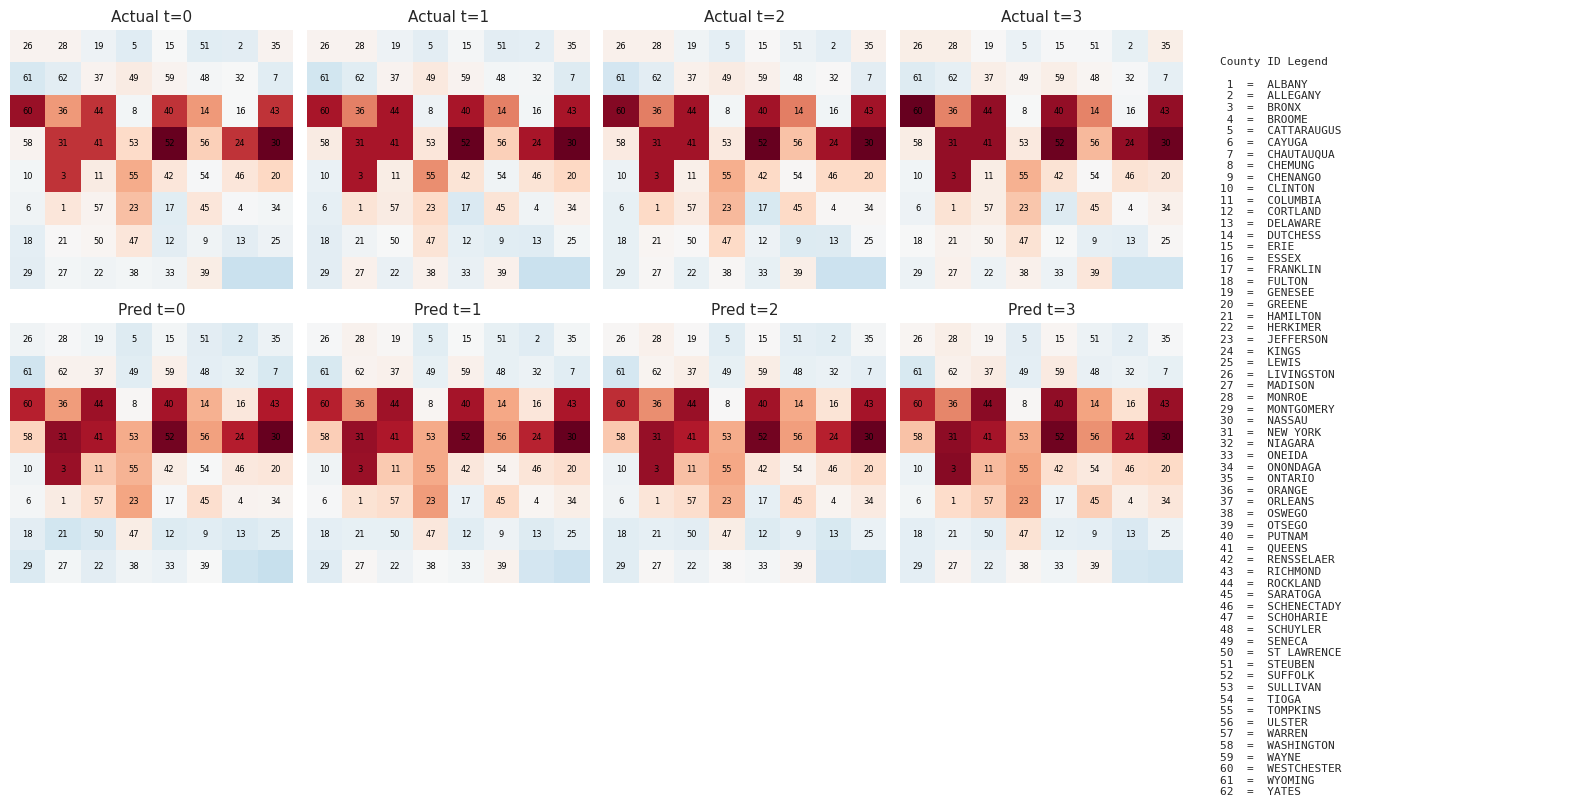

In [919]:
# Plot
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})
plot_time_evolution(preds_all, actuals_all, county_to_pos, county_to_id, timesteps=4)